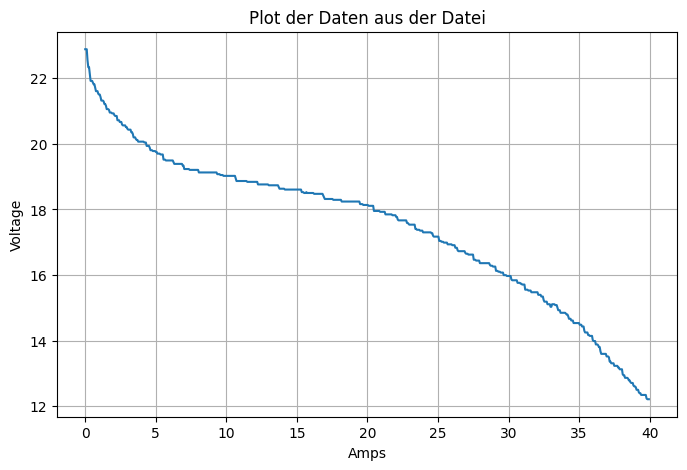

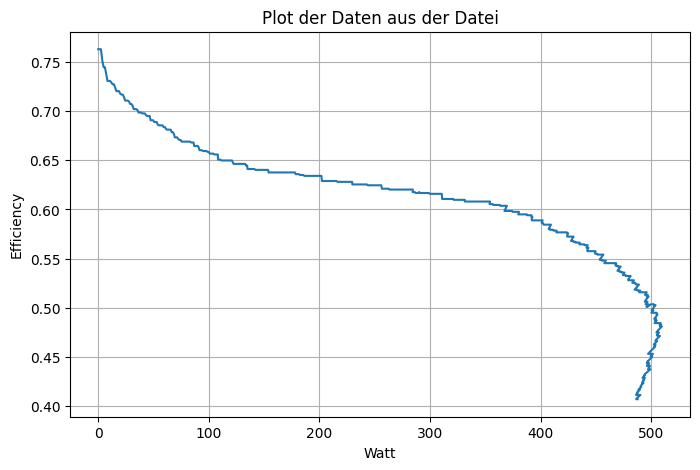

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Dateiname der Textdatei
dateiname = '../data/Fuel_cell_data/500W.txt'
number_cells = 24

# Daten einlesen (Spalten durch Tab oder Leerzeichen getrennt)
# skiprows=1 überspringt die Kopfzeile
daten = np.loadtxt(dateiname, skiprows=1)

# Spalten in separate Arrays
amps = daten[:, 0]
voltage = daten[:, 1]
efficiency = voltage/number_cells/1.25
power = amps*voltage

# Plot erstellen
plt.figure(figsize=(8,5))
plt.plot(amps, voltage)
plt.xlabel('Amps')
plt.ylabel('Voltage')
plt.title('Plot der Daten aus der Datei')
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(power, efficiency )
plt.xlabel('Watt')
plt.ylabel('Efficiency')
plt.title('Plot der Daten aus der Datei')
plt.grid(True)
plt.show()



In [8]:
from scipy.ndimage import gaussian_filter1d
from statsmodels.nonparametric.smoothers_lowess import lowess

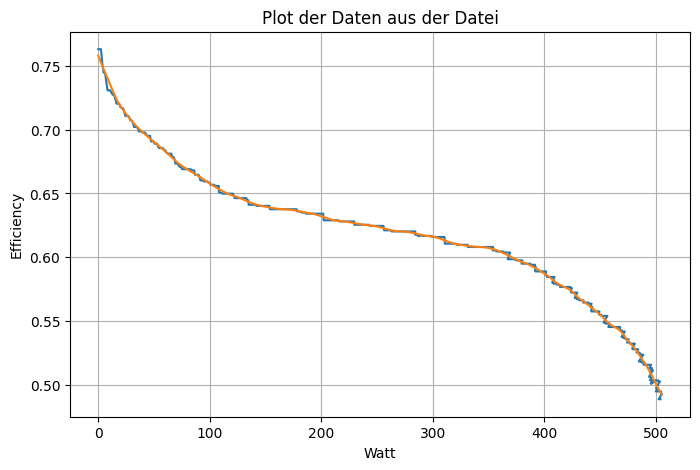

In [9]:
power = power[:630]
efficiency = efficiency[:630]

loess_result = lowess(efficiency, power, frac=0.05, it=0)

plt.figure(figsize=(8,5))
plt.plot(power, efficiency)
plt.plot(loess_result[:,0],loess_result[:,1])
plt.xlabel('Watt')
plt.ylabel('Efficiency')
plt.title('Plot der Daten aus der Datei')
plt.grid(True)
plt.show()


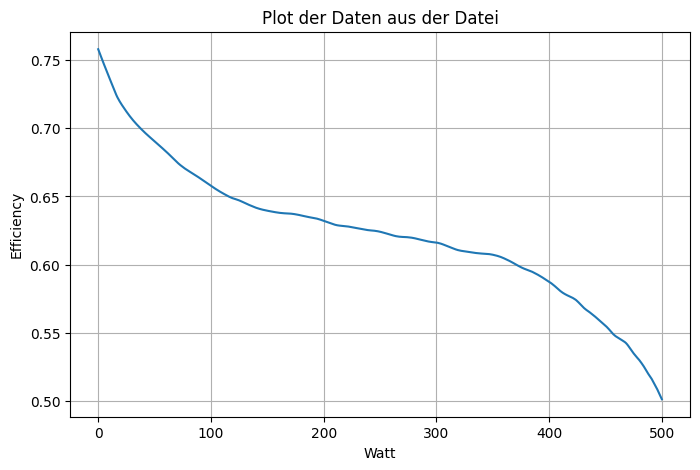

In [10]:
power_base = np.arange(0,501)
efficiency_value = np.interp(power_base,loess_result[:,0],loess_result[:,1])
plt.figure(figsize=(8,5))
plt.plot(power_base,efficiency_value)
plt.xlabel('Watt')
plt.ylabel('Efficiency')
plt.title('Plot der Daten aus der Datei')
plt.grid(True)
plt.show()

In [11]:
tosave = np.array([power_base,efficiency_value])
#np.save('UI-Curve500w',tosave)

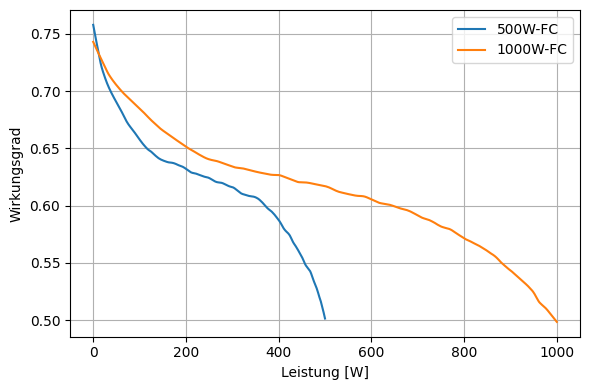

In [12]:
ui500 = np.load("../data/Fuel_cell_data/UI-Curve500w.npy")
ui1000 = np.load("../data/Fuel_cell_data/UI-Curve1000w.npy")
plt.figure(figsize=(6,4))
plt.plot(ui500[0],ui500[1], label="500W-FC")
plt.plot(ui1000[0],ui1000[1], label="1000W-FC")
# plt.title("Efficiency of two Fuel Cells (Reference is LHV!)")
plt.xlabel("Leistung [W]")
plt.ylabel("Wirkungsgrad")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("efficiency.pdf")
plt.show()